# Explore here

Forma del dataset (filas, columnas): (150, 6)

Primeras filas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target especie  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-nul

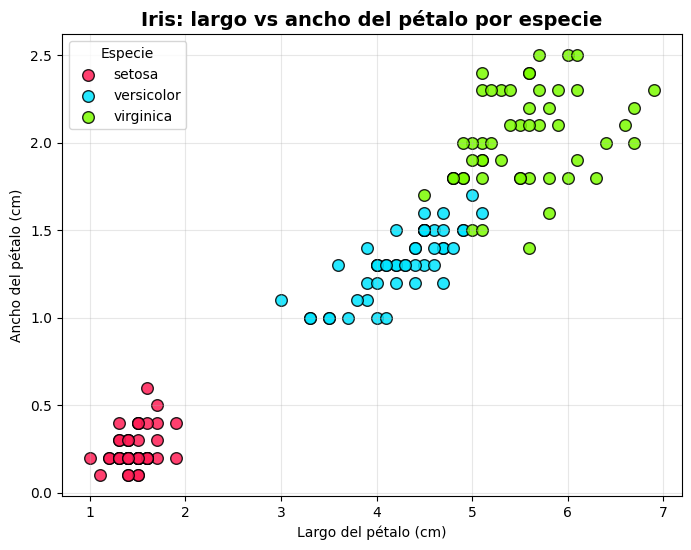

In [1]:
# Paso 1 - Cargar y explorar el dataset Iris
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Cargamos el dataset como un DataFrame de pandas
iris = load_iris(as_frame=True)
df = iris.frame  

df['especie'] = df['target'].map(dict(enumerate(iris.target_names)))

# --- Primer vistazo a los datos ---
print("Forma del dataset (filas, columnas):", df.shape)
print("\nPrimeras filas:")
print(df.head())
print("\nInformación general:")
df.info()
print("\nEstadísticas básicas:")
print(df.describe())
print("\nCantidad de ejemplos por especie:")
print(df['especie'].value_counts())

colores = {'setosa': '#FF1E56', 'versicolor': '#00E5FF', 'virginica': '#7CFC00'}

plt.figure(figsize=(8, 6))
for especie, color in colores.items():
    subset = df[df['especie'] == especie]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                c=color, label=especie, s=70, edgecolors='black', alpha=0.85)

plt.title('Iris: largo vs ancho del pétalo por especie', fontsize=14, fontweight='bold')
plt.xlabel('Largo del pétalo (cm)')
plt.ylabel('Ancho del pétalo (cm)')
plt.legend(title='Especie')
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Tamaño entrenamiento: 120 | Tamaño prueba: 30

Accuracy del modelo base: 0.9

Mejores parámetros encontrados: {'max_depth': 3, 'n_estimators': 50}

Accuracy del modelo optimizado: 0.967

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



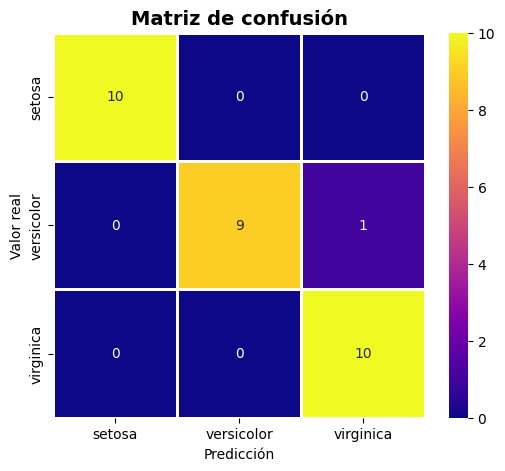

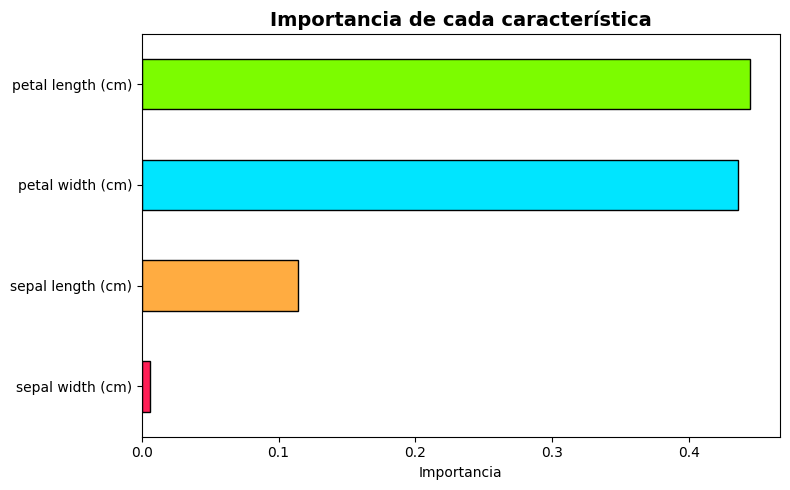


✅ Modelo guardado como 'modelo_iris.pkl'


In [3]:
# Paso 2 - Entrenar y optimizar un modelo de clasificación
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Cargamos los datos otra vez 
iris = load_iris(as_frame=True)
X = iris.data      
y = iris.target     

# 2) Separamos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Tamaño entrenamiento:", X_train.shape[0], "| Tamaño prueba:", X_test.shape[0])

# 3) Modelo base
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)
pred_base = modelo.predict(X_test)
print("\nAccuracy del modelo base:", round(accuracy_score(y_test, pred_base), 3))

# 4) Optimización: probamos varias combinaciones de hiperparámetros
parametros = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), parametros, cv=5)
grid.fit(X_train, y_train)
print("\nMejores parámetros encontrados:", grid.best_params_)
mejor_modelo = grid.best_estimator_

# 5) Evaluamos el mejor modelo
pred = mejor_modelo.predict(X_test)
print("\nAccuracy del modelo optimizado:", round(accuracy_score(y_test, pred), 3))
print("\nReporte de clasificación:")
print(classification_report(y_test, pred, target_names=iris.target_names))

matriz = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='plasma',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            linewidths=1, linecolor='white')
plt.title('Matriz de confusión', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

importancias = pd.Series(mejor_modelo.feature_importances_, index=X.columns).sort_values()
colores_barras = ['#FF1E56', '#FFAC41', '#00E5FF', '#7CFC00']
plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color=colores_barras, edgecolor='black')
plt.title('Importancia de cada característica', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Guardamos el modelo para usarlo en Flask (Paso 3)
joblib.dump(mejor_modelo, 'modelo_iris.pkl')
print("\n✅ Modelo guardado como 'modelo_iris.pkl'")

In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
# app.py - Aplicación web con Flask para usar el modelo Iris
from flask import Flask, render_template, request
import joblib
import pandas as pd

app = Flask(__name__)

# Cargamos el modelo entrenado 
modelo = joblib.load('modelo_iris.pkl')

# Nombres de las especies 
especies = ['Setosa', 'Versicolor', 'Virginica']

# Nombres de columnas EXACTOS con los que se entrenó el modelo
columnas = ['sepal length (cm)', 'sepal width (cm)',
            'petal length (cm)', 'petal width (cm)']

@app.route('/', methods=['GET', 'POST'])
def index():
    resultado = None
    if request.method == 'POST':
        
        largo_sepalo = float(request.form['largo_sepalo'])
        ancho_sepalo = float(request.form['ancho_sepalo'])
        largo_petalo = float(request.form['largo_petalo'])
        ancho_petalo = float(request.form['ancho_petalo'])

               datos = pd.DataFrame(
            [[largo_sepalo, ancho_sepalo, largo_petalo, ancho_petalo]],
            columns=columnas
        )
        prediccion = modelo.predict(datos)[0]
        resultado = especies[prediccion]

    return render_template('index.html', resultado=resultado)

if __name__ == '__main__':
    app.run(debug=True)

IndentationError: unexpected indent (819522446.py, line 28)